## COVID-19 Global Data Analysis::

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('/bin/ABC/country_wise_latest.csv')
display(df.head())

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [ ]:

# Group by WHO Region and sum the 'Confirmed' and 'Deaths' cases
regional_summary = df.groupby('WHO Region')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()
print(regional_summary)

              WHO Region  Confirmed  Deaths  Recovered   Active
0                 Africa     723207   12223     440645   270339
1               Americas    8839286  342732    4468616  4027938
2  Eastern Mediterranean    1490744   38339    1201400   251005
3                 Europe    3299523  211144    1993723  1094656
4        South-East Asia    1835297   41349    1156933   637015
5        Western Pacific     292428    8249     206770    77409


In [ ]:
# Sort by Confirmed cases for better visualization
regional_summary_sorted = regional_summary.sort_values(by='Confirmed', ascending=0)
print(regional_summary_sorted)

              WHO Region  Confirmed  Deaths  Recovered   Active
5        Western Pacific     292428    8249     206770    77409
0                 Africa     723207   12223     440645   270339
2  Eastern Mediterranean    1490744   38339    1201400   251005
4        South-East Asia    1835297   41349    1156933   637015
3                 Europe    3299523  211144    1993723  1094656
1               Americas    8839286  342732    4468616  4027938


Text(0, 0.5, 'WHO Region')

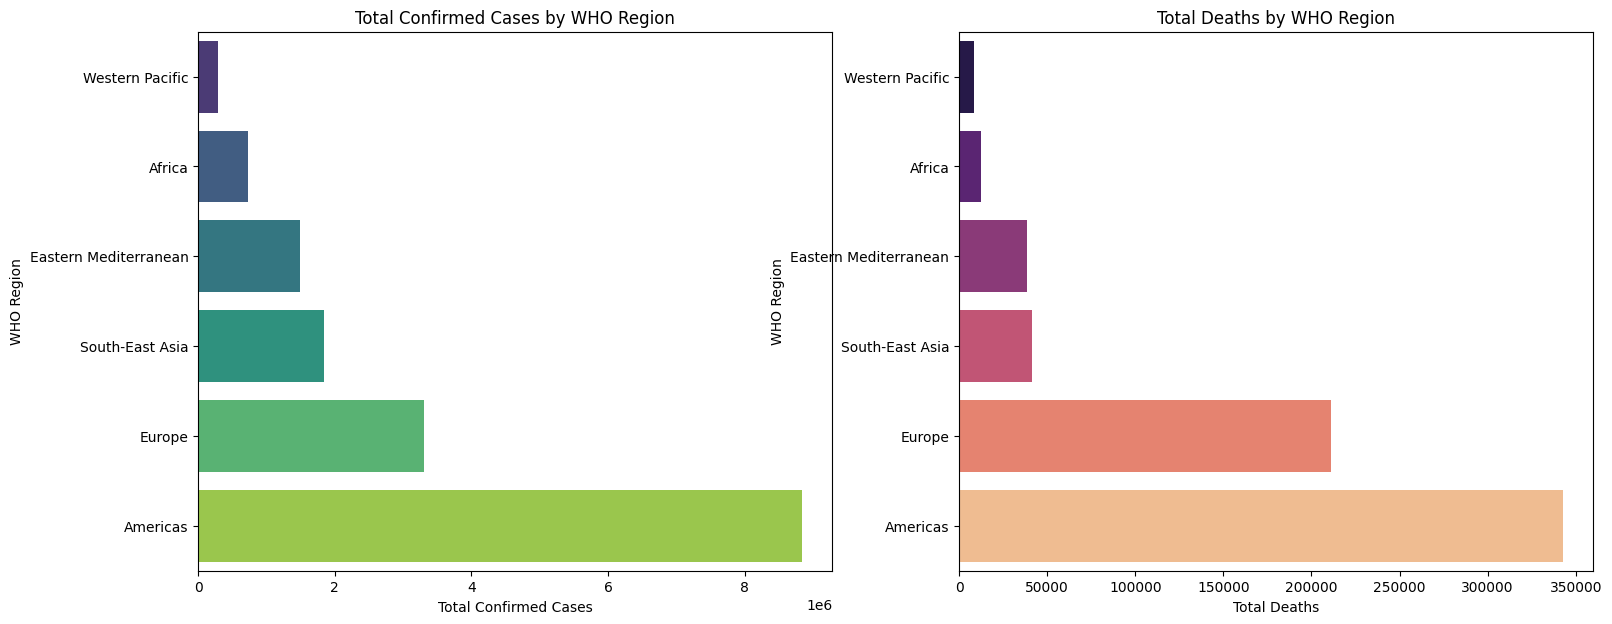

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(x='Confirmed', y='WHO Region', hue='WHO Region',data=regional_summary_sorted, ax=axes[0], palette='viridis')
axes[0].set_title('Total Confirmed Cases by WHO Region')
axes[0].set_xlabel('Total Confirmed Cases')
axes[0].set_ylabel('WHO Region')



sns.barplot(x='Deaths', y='WHO Region', hue='WHO Region',data=regional_summary_sorted, ax=axes[1], palette='magma')
axes[1].set_title('Total Deaths by WHO Region')
axes[1].set_xlabel('Total Deaths')
axes[1].set_ylabel('WHO Region')



In [ ]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
# Top 10 Countries by Confirmed Cases
top_10_confirmed = df.nlargest(10, 'Confirmed')

In [ ]:
# Top 10 Countries by Deaths
top_10_deaths = df.nlargest(10, 'Deaths')

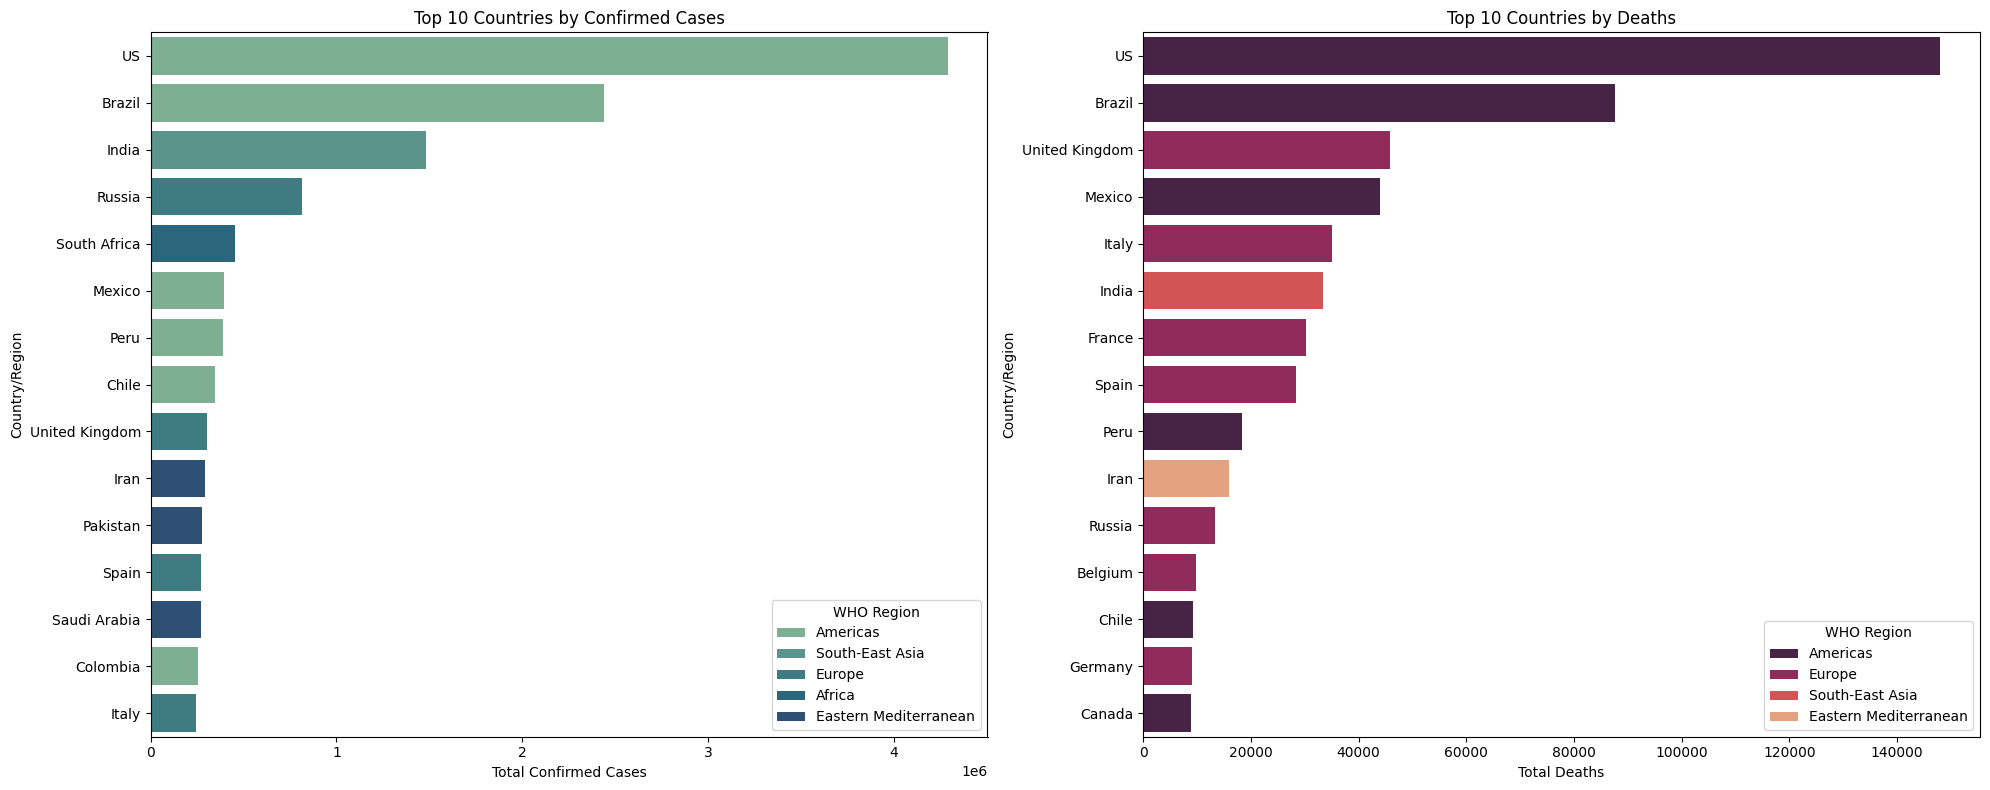

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(x='Confirmed', y='Country/Region', hue='WHO Region',data=top_10_confirmed, ax=axes[0], palette='crest')
axes[0].set_title('Top 10 Countries by Confirmed Cases')
axes[0].set_xlabel('Total Confirmed Cases')
axes[0].set_ylabel('Country/Region')

sns.barplot(x='Deaths', y='Country/Region',hue='WHO Region', data=top_10_deaths, ax=axes[1], palette='rocket')
axes[1].set_title('Top 10 Countries by Deaths')
axes[1].set_xlabel('Total Deaths')
axes[1].set_ylabel('Country/Region')

plt.tight_layout()
plt.show()

In [ ]:
df['Mortality_Rate'] = (df['Deaths'] / df['Confirmed']) * 100

In [65]:

# Sort by Mortality Rate and display the top 10 countries
top_10_mortality = df.nlargest(10, 'Mortality_Rate')

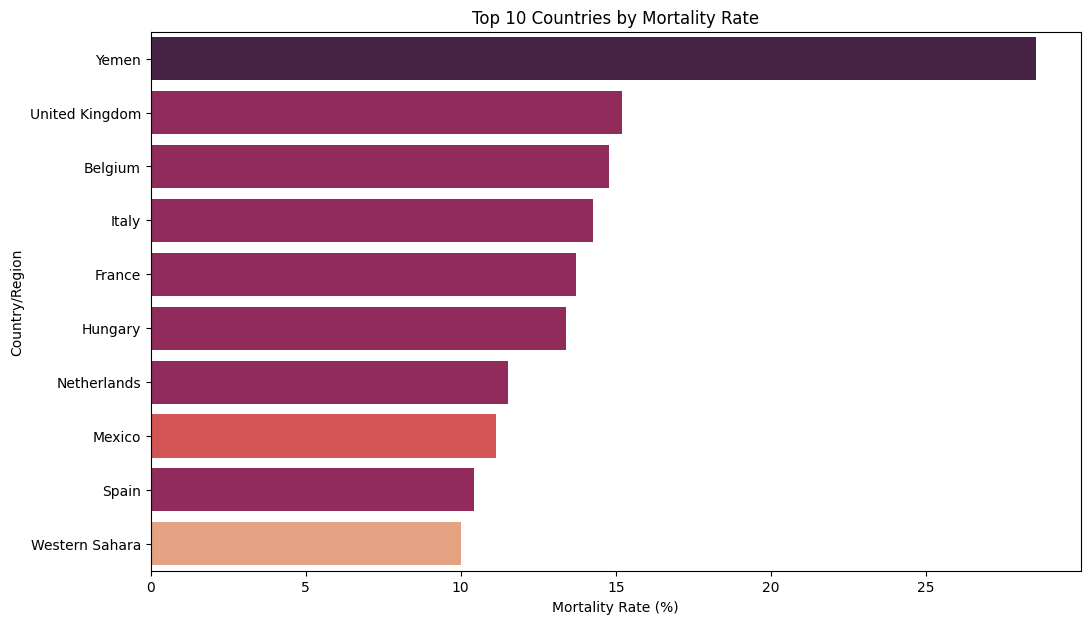

,Country/Region,Confirmed,Deaths,Mortality_Rate
184,Yemen,1691,483,28.562980
177,United Kingdom,301708,45844,15.194824
16,Belgium,66428,9822,14.785934
85,Italy,246286,35112,14.256596
61,France,220352,30212,13.710790
77,Hungary,4448,596,13.399281
120,Netherlands,53413,6160,11.532773
111,Mexico,395489,44022,11.131030
157,Spain,272421,28432,10.436787
183,Western Sahara,10,1,10.000000


In [66]:
df['Mortality_Rate'] = (df['Deaths'] / df['Confirmed']) * 100
plt.figure(figsize=(12, 7))
sns.barplot(x='Mortality_Rate', y='Country/Region',hue = 'WHO Region', data=top_10_mortality, palette='rocket',legend=False)
plt.title('Top 10 Countries by Mortality Rate')
plt.xlabel('Mortality Rate (%)')
plt.ylabel('Country/Region')
plt.show()

display(top_10_mortality[['Country/Region', 'Confirmed', 'Deaths', 'Mortality_Rate']])